In [5]:
import os
print("Walmart.csv" in os.listdir())

True


FIRST 5 ROWS
   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  

SHAPE
(6435, 8)

COLUMNS
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        ------

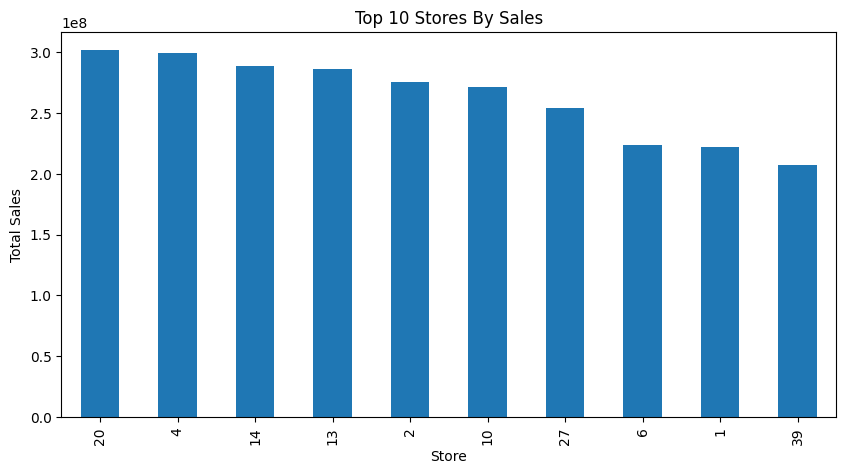


HOLIDAY SALES ANALYSIS
Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


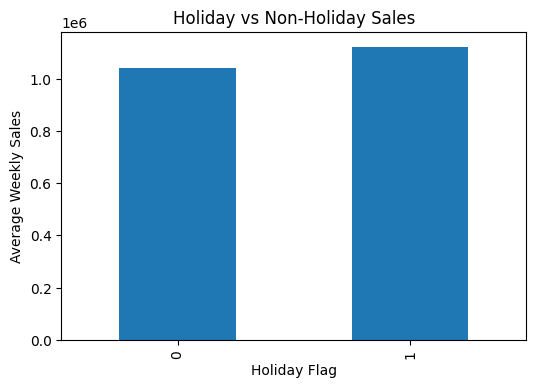

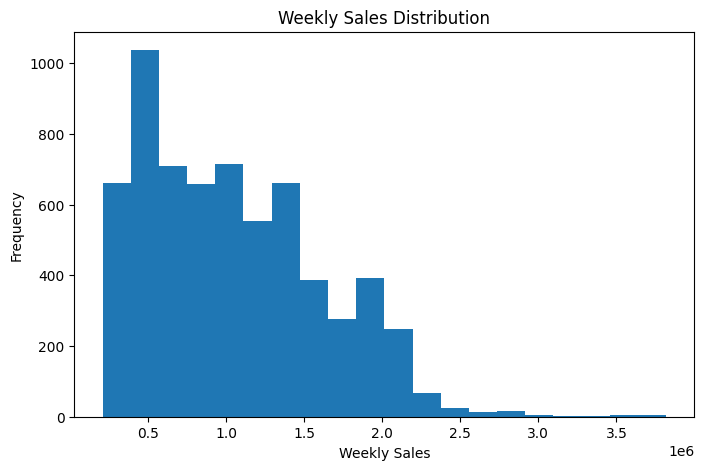


MONTHLY SALES
Date
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64


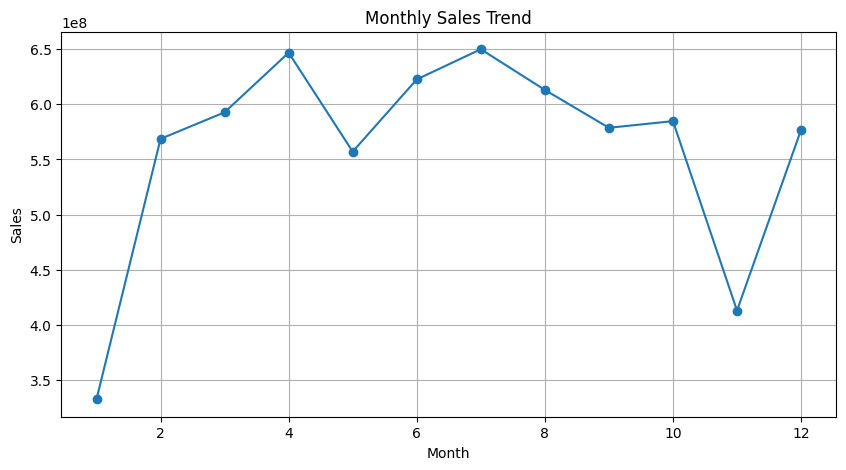

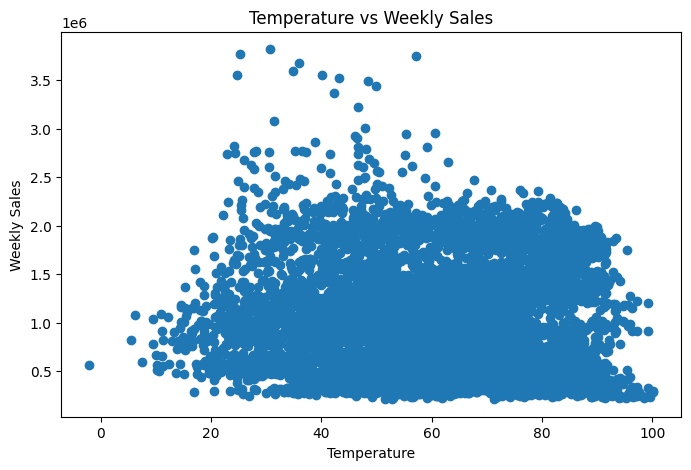

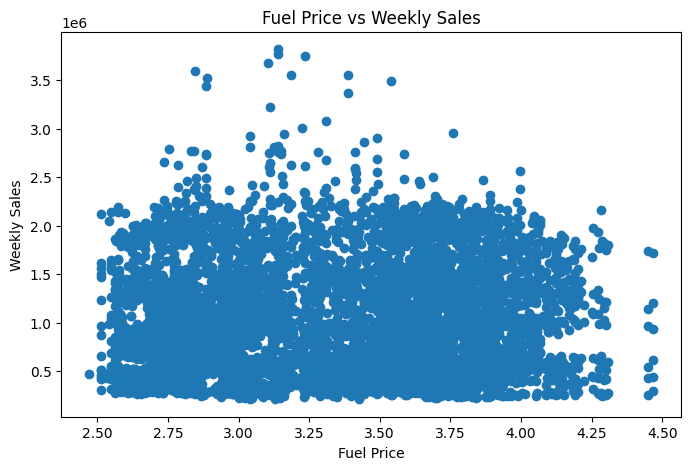

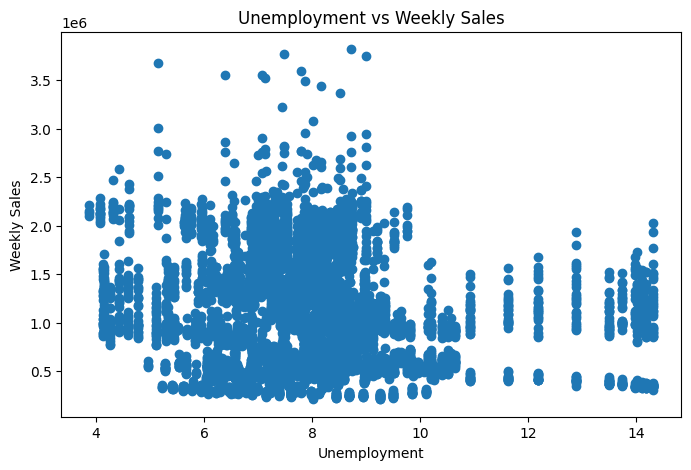


CORRELATION MATRIX
              Weekly_Sales  Temperature  Fuel_Price       CPI  Unemployment
Weekly_Sales      1.000000    -0.063810    0.009464 -0.072634     -0.106176
Temperature      -0.063810     1.000000    0.144982  0.176888      0.101158
Fuel_Price        0.009464     0.144982    1.000000 -0.170642     -0.034684
CPI              -0.072634     0.176888   -0.170642  1.000000     -0.302020
Unemployment     -0.106176     0.101158   -0.034684 -0.302020      1.000000

BEST STORE
20

WORST STORE
33

 ANALYSIS COMPLETED SUCCESSFULLY


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Walmart.csv")

print("FIRST 5 ROWS")
print(df.head())

print("\nSHAPE")
print(df.shape)

print("\nCOLUMNS")
print(df.columns)

print("\nINFO")
print(df.info())

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nSTATISTICAL SUMMARY")
print(df.describe())

total_sales = df['Weekly_Sales'].sum()

print("\nTOTAL SALES")
print(total_sales)

average_sales = df['Weekly_Sales'].mean()

print("\nAVERAGE SALES")
print(average_sales)

max_sales = df['Weekly_Sales'].max()

print("\nMAXIMUM SALES")
print(max_sales)

min_sales = df['Weekly_Sales'].min()

print("\nMINIMUM SALES")
print(min_sales)

store_sales = df.groupby('Store')['Weekly_Sales'].sum()

top10 = store_sales.sort_values(
    ascending=False).head(10)

print("\nTOP 10 STORES")
print(top10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title("Top 10 Stores By Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

holiday_sales = df.groupby(
    'Holiday_Flag')['Weekly_Sales'].mean()

print("\nHOLIDAY SALES ANALYSIS")
print(holiday_sales)

plt.figure(figsize=(6,4))
holiday_sales.plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['Weekly_Sales'], bins=20)
plt.title("Weekly Sales Distribution")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

df['Date'] = pd.to_datetime(
    df['Date'],
    dayfirst=True
)

monthly_sales = df.groupby(
    df['Date'].dt.month
)['Weekly_Sales'].sum()

print("\nMONTHLY SALES")
print(monthly_sales)

plt.figure(figsize=(10,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df['Temperature'],
    df['Weekly_Sales']
)

plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df['Fuel_Price'],
    df['Weekly_Sales']
)

plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(
    df['Unemployment'],
    df['Weekly_Sales']
)

plt.title("Unemployment vs Weekly Sales")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")
plt.show()

print("\nCORRELATION MATRIX")

correlation = df[
    [
        'Weekly_Sales',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment'
    ]
].corr()

print(correlation)

best_store = store_sales.idxmax()

print("\nBEST STORE")
print(best_store)

worst_store = store_sales.idxmin()

print("\nWORST STORE")
print(worst_store)

print("\n ANALYSIS COMPLETED SUCCESSFULLY")